### 1. Data Overview

In [65]:
import os, pandas as pd, numpy as np
from matplotlib import pyplot as plt
from scipy.signal import medfilt
from scipy.stats import iqr
from scipy.fft import fft
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier, plot_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, f1_score

pd.set_option("display.max_columns", None)

DATASET_DIR = "Datasets/fall_detection"

In [ ]:
def load_and_label(path, label):
    df = pd.read_csv(path)
    
    df.columns = ['x', 'y', 'z']
    df['x'] = medfilt(df['x'], kernel_size=3)
    df['y'] = medfilt(df['y'], kernel_size=3)
    df['z'] = medfilt(df['z'], kernel_size=3)
    df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
    df['jerk'] = df['mag'].diff().fillna(0)
    df['label'] = label
    return df

fall_samples = [load_and_label(os.path.join(DATASET_DIR, "Fall", csv), "Fall") for csv in os.listdir(os.path.join(DATASET_DIR, "Fall")) if csv.endswith(".csv")]
lying_samples = [load_and_label(os.path.join(DATASET_DIR, "Lying", csv), "Lying") for csv in os.listdir(os.path.join(DATASET_DIR, "Lying")) if csv.endswith(".csv")]
sit_samples = [load_and_label(os.path.join(DATASET_DIR, "Sit", csv), "Sit") for csv in os.listdir(os.path.join(DATASET_DIR, "Sit")) if csv.endswith(".csv")]
walking_samples = [load_and_label(os.path.join(DATASET_DIR, "Walking", csv), "Walking") for csv in os.listdir(os.path.join(DATASET_DIR, "Walking")) if csv.endswith(".csv")]


In [ ]:
def plot_magnitude(samples, title, max_samples=3):
    plt.figure(figsize=(10, 5))

    for i, df in enumerate(samples[:max_samples]):
        t = np.arange(len(df)) / 25.0
        plt.plot(t, df['mag'], alpha=0.6)

    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Magnitude (g)')
    plt.grid(True)
    plt.savefig(f"Images/{title}_magnitude.svg", format="svg")
    plt.show()

def plot_jerk(samples, title, max_samples=3):
    plt.figure(figsize=(10, 5))

    for i, df in enumerate(samples[:max_samples]):
        t = np.arange(len(df)) / 25.0
        plt.plot(t, df['jerk'], alpha=0.6)

    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Jerk')
    plt.grid(True)
    plt.savefig(f"Images/{title}_jerk.svg", format="svg")
    plt.show()

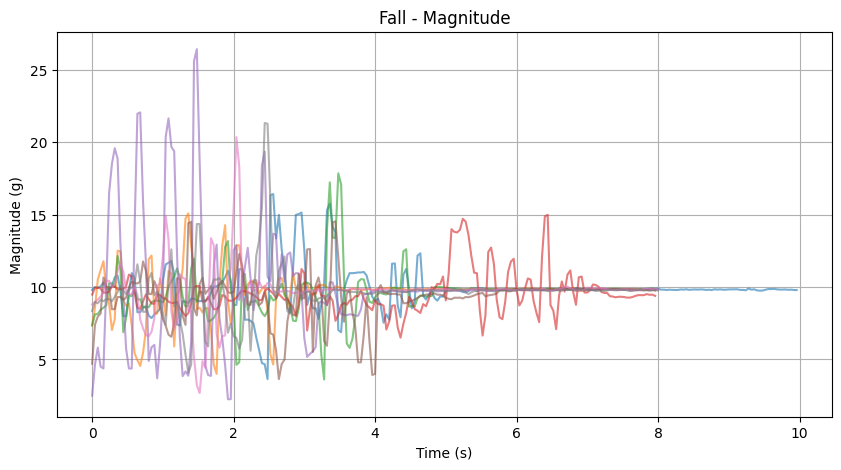

In [68]:
plot_magnitude(fall_samples, "Fall - Magnitude", 8)

This graph shows the total resultant acceleration over time. The sharp, high-amplitude peaks (reaching up to 25g) represent the sudden, forceful impacts or collisions occurring during the fall, while the subsequent leveling out near 10 m/s² (or 1g) indicates the device returning to a state of rest or steady motion.

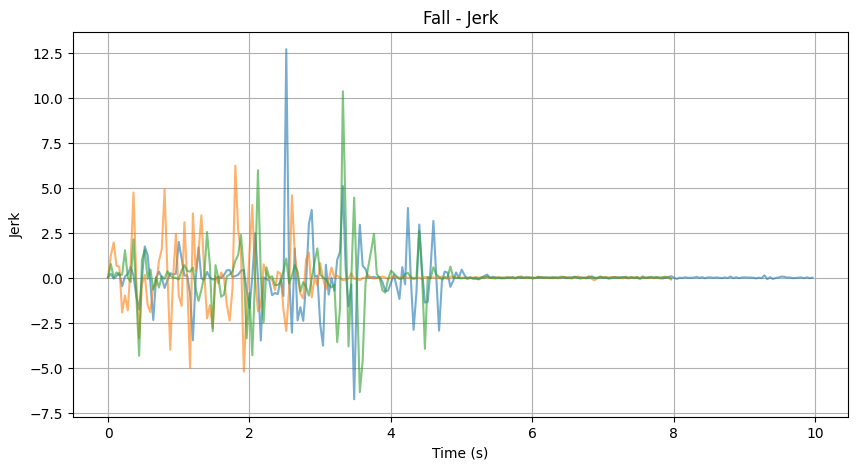

In [69]:
plot_jerk(fall_samples, "Fall - Jerk")

This graph illustrates the rate of change in acceleration, highlighting how "abrupt" the movements are. The intense clusters of spikes between 0 and 5 seconds pinpoint the exact moments of violent transitions and jarring impacts, where the forces acting on the sensor changed most rapidly.

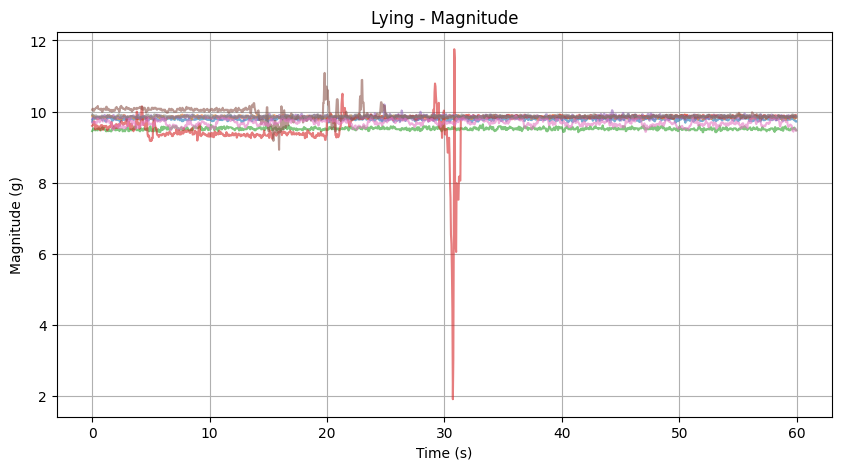

In [70]:
plot_magnitude(lying_samples, "Lying - Magnitude", 8)

This graph represents a period of rest, where the steady magnitude near 10 m/s² indicates a stationary lying position. The prominent dip and spike in the red trace (around 31s) signify a significant bodily shift or "re-positioning" event, causing a momentary deviation from the constant gravitational force before returning to a baseline state.

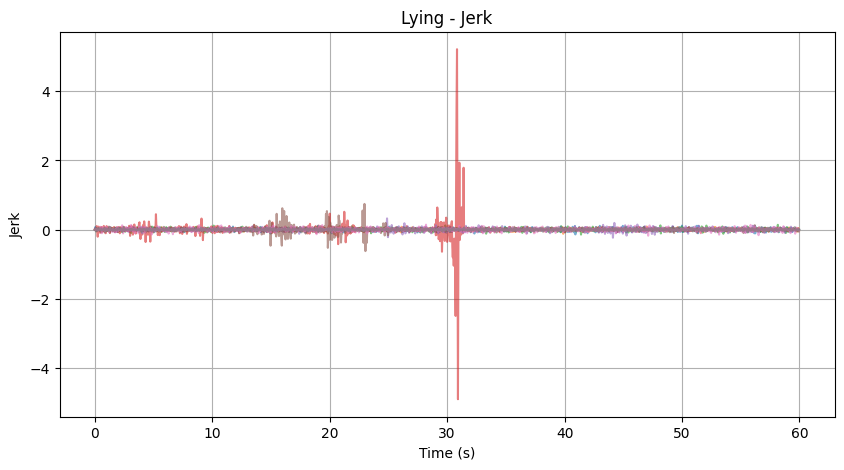

In [71]:
plot_jerk(lying_samples, "Lying - Jerk", 8)

This graph shows very low-intensity fluctuations centered around zero, representing "background noise" rather than actual movement. The absence of large spikes confirms that the subject remained mostly still, as even the minor postural shifts were performed slowly enough to avoid high rates of change in acceleration.

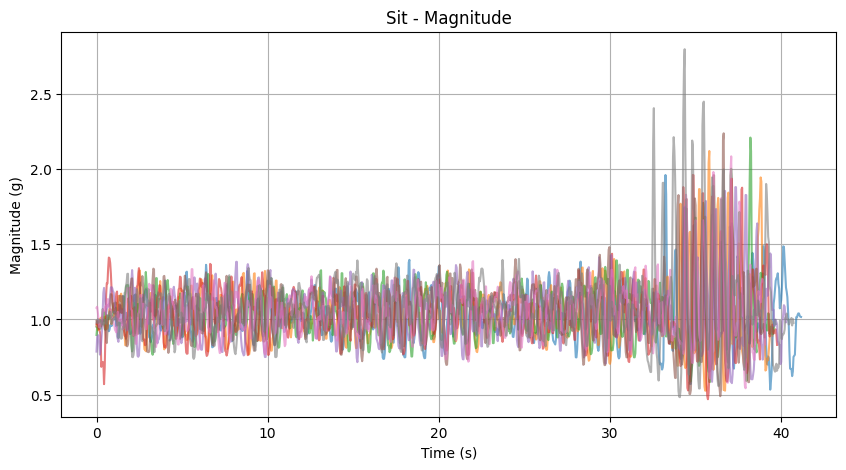

In [72]:
plot_magnitude(sit_samples, "Sit - Magnitude", 8)

This graph displays the characteristic "micro-vibrations" of a sedentary activity, where the magnitude stays consistently between 0.75g and 1.25g. The increased oscillation intensity toward the end of the recording (after 32s) likely captures the transition or movement involved in standing up or adjusting position after a period of sitting.

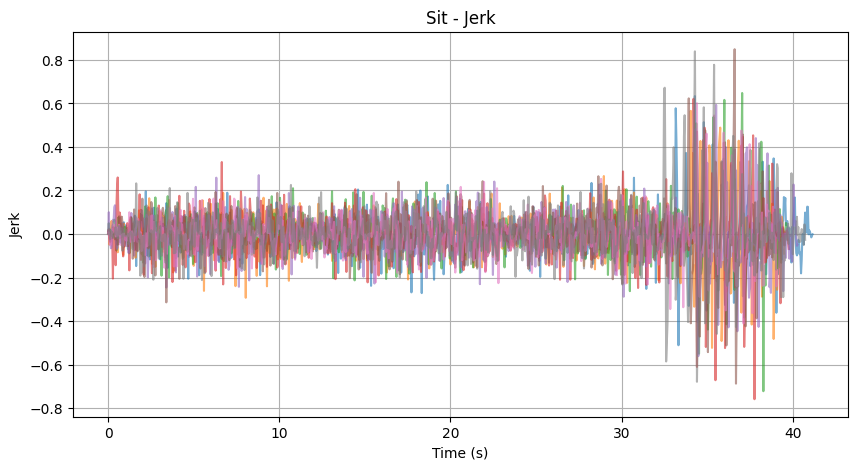

In [73]:
plot_jerk(sit_samples, "Sit - Jerk", 8)

This graph shows low-level, high-frequency oscillations centered at zero, which correspond to the subtle, continuous adjustments of a seated body. The sudden increase in amplitude after the 32s mark reflects the more intentional and rapid physical movement of the subject changing their posture or preparing to stand.

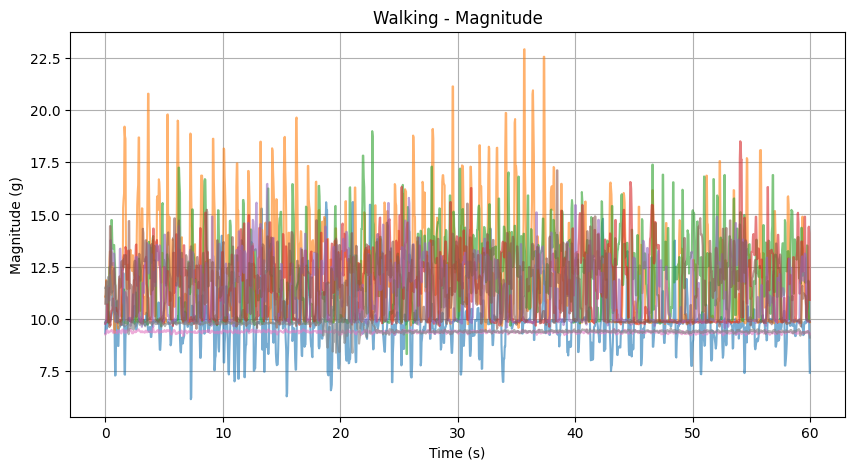

In [74]:
plot_magnitude(walking_samples, "Walking - Magnitude", 8)

This graph shows a highly rhythmic series of peaks, representing the periodic impact of each foot step. The variation in peak heights, with some reaching above 20g, reflects the increased physical effort and vertical force required when transitioning from flat-ground walking to ascending or descending stairs.

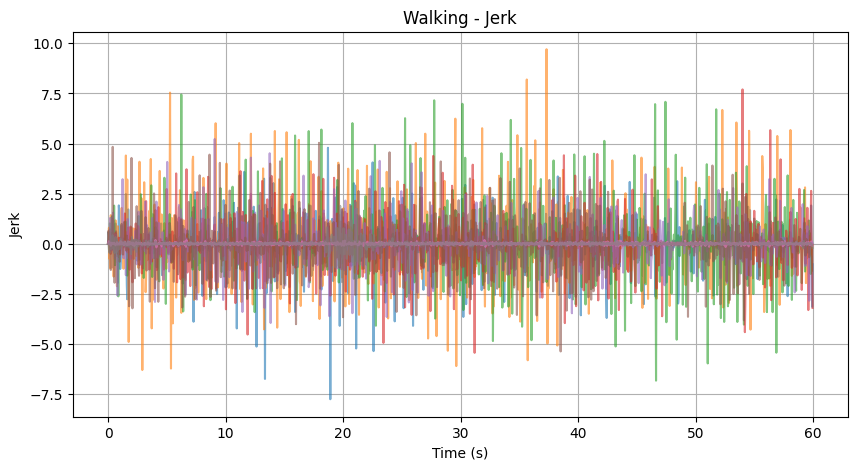

In [75]:
plot_jerk(walking_samples, "Walking - Jerk", 8)

The jerk profile for walking shows a dense, continuous sequence of spikes that correspond to the rapid changes in acceleration during each step cycle. Unlike the "quiet" resting activities, the frequent peaks between 5 and 7.5 highlight the repetitive "jarring" nature of walking and the dynamic balance adjustments made while navigating stairs.

### 2. Data Preprocessing

The raw accelerometer data consists of high-frequency time-series measurements that are often redundant and contain sensor noise. To effectively classify human falls, it is necessary to transform these raw signals into a structured set of statistical and frequency-domain descriptors. This process reduces dimensionality while preserving the underlying physical characteristics of each activity.

| Feature Category | Description | Domain Relevance |
| :--- | :--- | :--- |
| **Magnitude Statistics** | Mean, Standard Deviation, Min/Max | Quantifies the intensity and range of gravitational forces. |
| **Jerk Statistics** | Rate of change of acceleration | Analyzes the abruptness of transitions. High jerk values distinguish the violent impacts from controlled movements. |
| **SMA (Signal Magnitude Area)** | Sum of absolute values across all axes | Measures the total volume of physical activity. It is a reliable indicator for distinguishing between sedentary states and active locomotion. |
| **Spectral Energy (FFT)** | Power distribution across frequency bins | Identifies the rhythmic components of the activity. Walking exhibits distinct periodic peaks, whereas falls produce non-periodic, wide-band energy. |
| **IQR (Interquartile Range)** | Spread of the middle 50 percent of data | Provides a robust measure of signal dispersion that is less sensitive to outliers than standard deviation. |
| **Energy** | Mean of the squared signal | Represents the total power output within a time window, used to separate high-intensity activities from resting states. |

The feature extraction process is based on established Human Activity Recognition (HAR) research. Following the methodologies of [1] and [2], I have implemented a combination of time-domain statistics (mean, std, max) and frequency-domain components (FFT energy).

In [76]:
def extract_features(window):
    features = {}
    for axis in ['x', 'y', 'z', 'mag', 'jerk']:
        s = window[axis]
        features[f'{axis}_mean'] = s.mean()
        features[f'{axis}_std'] = s.std()
        features[f'{axis}_max'] = s.max()
        features[f'{axis}_min'] = s.min()
        features[f'{axis}_iqr'] = iqr(s)
        features[f'{axis}_energy'] = (s**2).mean()
    features['sma'] = (window['x'].abs() + window['y'].abs() + window['z'].abs()).mean()
    features['peak_mag'] = window['mag'].max()
    fft_vals = np.abs(fft(window['mag'].values))[:64]
    features['fft_energy_1'] = fft_vals[1:10].mean()
    features['fft_energy_2'] = fft_vals[10:30].mean()
    features['fft_energy_3'] = fft_vals[30:64].mean()
    features['label'] = window['label'].iloc[0]
    return features

processed_samples = []

def process_accelerometer_sample(df):
    WINDOW, STEP = 128, 64
    rows = []
    for start in range(0, len(df) - WINDOW, STEP):
        window = df.iloc[start:start+WINDOW]
        rows.append(extract_features(window))
    return rows

for sample in fall_samples + lying_samples + sit_samples + walking_samples + phone_drop_samples:
    processed_samples.extend(process_accelerometer_sample(sample))

features_df = pd.DataFrame(processed_samples)
features_df.shape

(3942, 36)

The continuous accelerometer signal is partitioned into discrete segments using a window size of 128 samples and a step size of 64 samples. This 50% overlap ensures that transient events, such as the peak impact in a fall, are fully captured within a window rather than being split at a boundary. This segmentation provides the necessary temporal context to calculate statistical and frequency-domain features for activity classification.

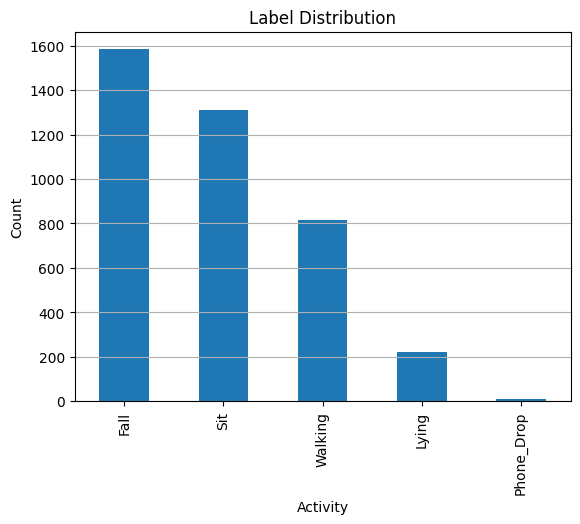

In [ ]:
#Plot Label Distribution bar chart
features_df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.grid(axis='y')
plt.savefig("Images/label_distribution.svg", format="svg")
plt.show()

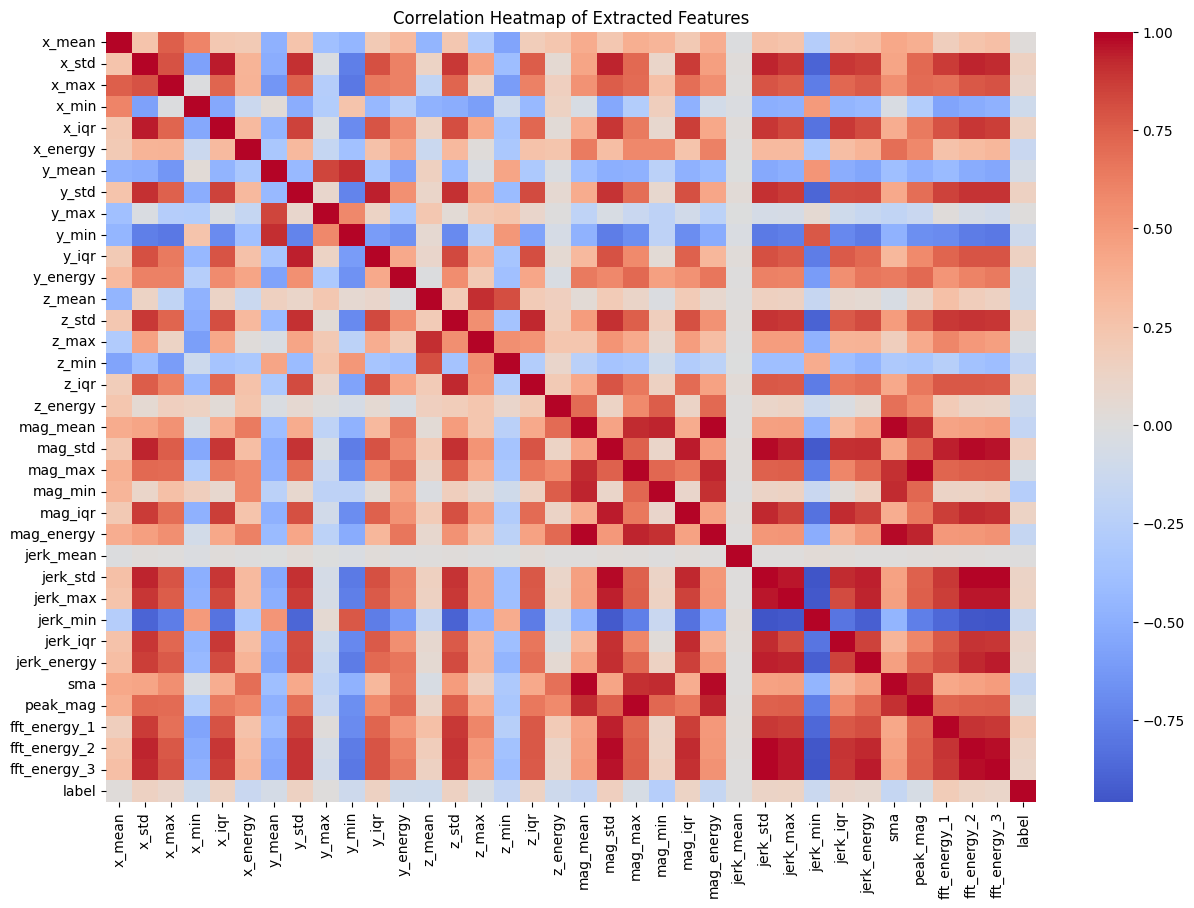

In [ ]:
label_mapping = {
    "Lying": 0,
    "Sit": 1,
    "Walking": 2, 
    "Fall": 3,
}    
features_df['label'] = features_df['label'].map(lambda x: label_mapping[x])

corr_matrix = features_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Extracted Features')
plt.savefig("Images/correlation_heatmap.svg", format="svg")
plt.show()

The correlation heatmap shows high redundancy among derived features. While these features are mathematically linked, I have retained them to allow the model's feature selection process to identify the most statistically significant descriptors for fall detection without manual bias.

### 3. Training and Evaluation

#### 3.1 Multiclass Classification

In [79]:
X = features_df.drop(columns=['label'])
y = features_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3153, 35), (3153,), (789, 35), (789,))

In [80]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### 3.1.1 Support Vector Classifier

In [81]:
param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 'scale'],
    'kernel': ['rbf', 'poly', 'linear']    
}
f1_multiclass = make_scorer(f1_score, average='weighted')
svm_model = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring=f1_multiclass, n_jobs=-1)
svm_model.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...rage=weighted)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [82]:
svm_preds = svm_model.predict(X_test_scaled)
print(classification_report(y_test, svm_preds, target_names=label_mapping.keys()))

              precision    recall  f1-score   support

       Lying       0.93      0.98      0.96        44
         Sit       0.79      0.90      0.84       248
     Walking       0.97      0.99      0.98       158
        Fall       0.91      0.81      0.86       336
  Phone_Drop       1.00      0.67      0.80         3

    accuracy                           0.88       789
   macro avg       0.92      0.87      0.89       789
weighted avg       0.89      0.88      0.88       789



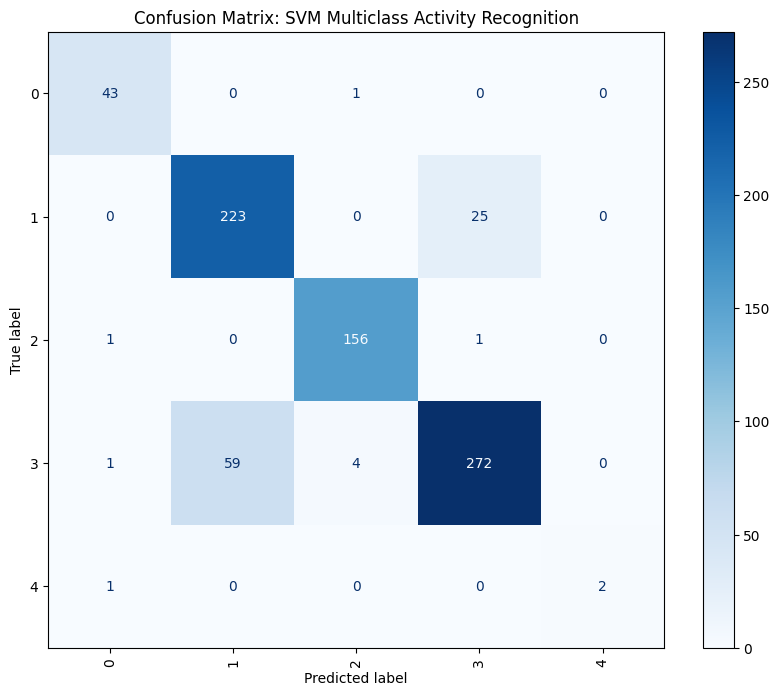

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, svm_preds), display_labels=svm_model.classes_)

disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: SVM Multiclass Activity Recognition')
plt.savefig("Images/svm_confusion_matrix.svg", format="svg")
plt.show()

Support Vector Classifier achieves an accuracy of 87% and the confusion matrix shows it is able to distinguish between the 4 acitivities very effectively.

##### 3.1.1 LightGBM

In [84]:
lgbm_param_grid = {
    "n_estimators": [10, 50, 100],
    "learning_rate": [0.03, 0.1],
    "num_leaves": [31, 63],
    "max_depth": [-1, 10],
    "min_child_samples": [20, 50]
}

lgbm_model = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity = -1, class_weight='balanced'),
    lgbm_param_grid,
    cv=5,
    scoring=f1_multiclass,
    n_jobs=-1,
)
lgbm_model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.1], 'max_depth': [-1, 10], 'min_child_samples': [20, 50], 'n_estimators': [10, 50, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...rage=weighted)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [85]:
lgbm_preds = lgbm_model.predict(X_test)
print(classification_report(y_test, lgbm_preds, target_names=label_mapping.keys()))

              precision    recall  f1-score   support

       Lying       0.96      0.98      0.97        44
         Sit       0.84      0.91      0.87       248
     Walking       0.99      0.98      0.98       158
        Fall       0.92      0.86      0.89       336
  Phone_Drop       0.67      0.67      0.67         3

    accuracy                           0.91       789
   macro avg       0.87      0.88      0.88       789
weighted avg       0.91      0.91      0.91       789



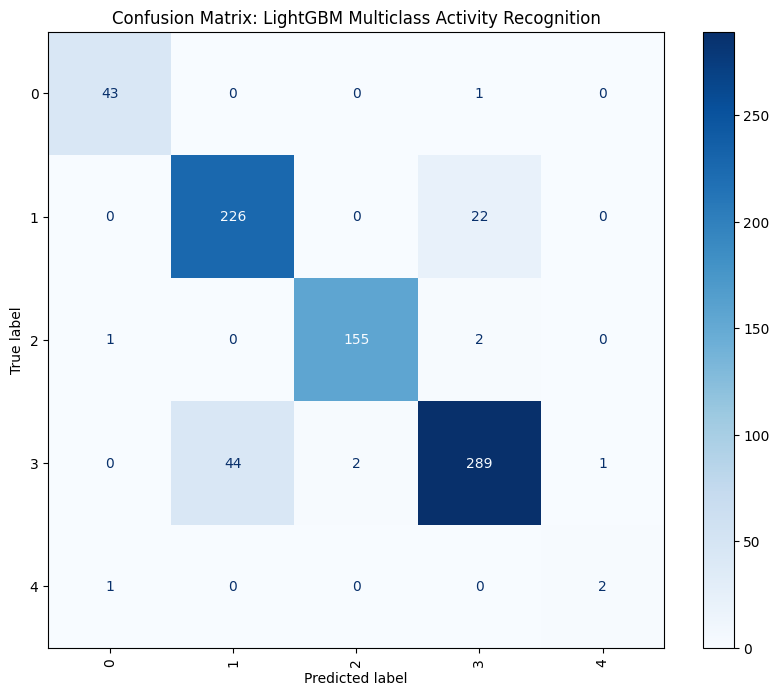

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, lgbm_preds), display_labels=lgbm_model.classes_)

disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix: LightGBM Multiclass Activity Recognition')
plt.savefig("Images/lgbm_confusion_matrix.svg", format="svg")
plt.show()

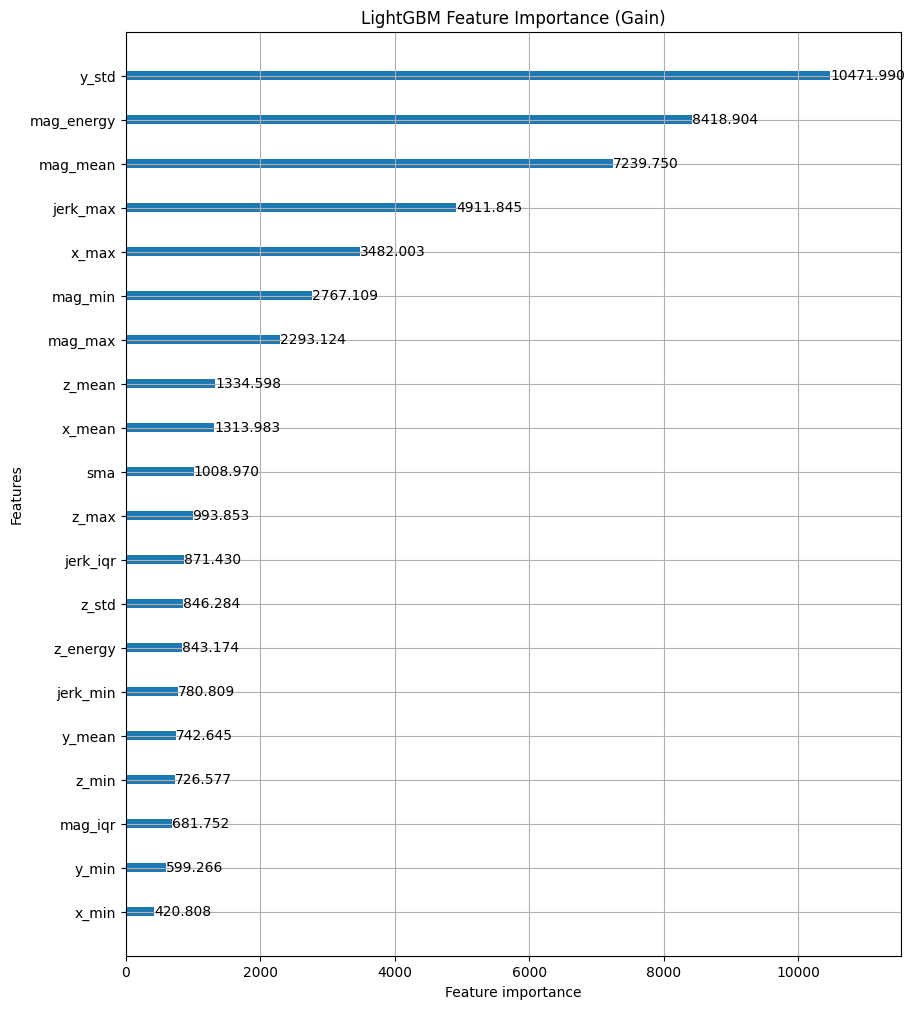

In [ ]:
best_lgbm = lgbm_model.best_estimator_

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_lgbm, ax=ax, importance_type='gain', max_num_features=20)

plt.title('LightGBM Feature Importance (Gain)')
plt.savefig("Images/lgbm_feature_importance.svg", format="svg")
plt.show()

The feature importance plot demonstrates that magnitude-based descriptors (specifically mag_max and mag_energy) are the primary drivers of model performance, validating their role as critical markers for high-impact fall events. While the correlation heatmap previously flagged multicollinearity, this "Gain" analysis reveals that the model still extracts significant predictive value from these related features to distinguish between activities. The high ranking of y_std and various axis-specific means further suggests that spatial orientation and vertical acceleration patterns are essential secondary factors in accurately classifying falls versus daily movements.

In [88]:
import joblib
joblib.dump(scaler, "Models/scaler.joblib")
joblib.dump(svm_model, "Models/svm_model.joblib")
joblib.dump(lgbm_model, "Models/lgbm_model.joblib")

['Models/lgbm_model.joblib']

### References

[1] D. Anguita, A. Ghio, L. Oneto, X. Parra, and J. L. Reyes-Ortiz, "A public domain dataset for human activity recognition using smartphones," in Proceedings of the 21st European Symposium on Artificial Neural Networks, Computational Intelligence and Machine Learning (ESANN), Bruges, Belgium, 2013, pp. 491–496

[2] Figueira, C., Matias, R., and Gamboa, H. (2016). Body location independent activity monitoring. In Proceedings of the 9th International Joint Conference on Biomedical Engineering Systems and Technologies Volume 4: BIOSIGNALS, pages 190–197. INSTICC, SciTePress